# Linear model selection and model regularization
----
선형모형을 다시 돌아보자.

$$ Y = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p + \epsilon $$

선형모형은 간단함에도 불구하고, interpretablity가 좋고, 종종 좋은 predictive performance를 보인다.

이 장에서는 선형모형의 기본적인 장점은 유지하면서 단점을 보완하는 대안들을 살펴본다.

### Why consider alternatives?

* Prediction accuracy : $p > n$이면 최소제곱 회귀계수가 유일하게 결정되지 않을 수 있다. 또한 설명변수가 많으면 과적합이 발생하기 쉽다. 추정될 모수의 수를 제한하여 추정량의 분산을 줄이고 예측 정확성을 높인다. 설명변수가 많거나 서로 강하게 상관되어 있으면 최소제곱 추정량의 변동성이 커질 수 있는데, 정규화는 약간의 bias를 허용하는 대신 추정량의 분산을 줄일 수 있다.

* Model interpretability : 불필요한 feature 변수를 제외하여 모형을 보다 해석 가능하도록 만든다. feature selection 혹은 variable selection이 자동으로 이루어지는 방법에 대해 알아본다.

### 세가지 방법

* Subset selection : $p$개의 predictor 중에서 반응변수와 연관이 있을 것으로 생각되는 부분 집합을 식별하는 방법.

* Shrinkage (regularization) : $p$개의 predictor를 모형 적합에 사용하지만, 그 중의 일부 predictor들의 해당되는 계수는 0 혹은 0과 매우 가까운 값으로 추정된다. 

* Dimension reduction : $p$개의 predictor를 $M$-dimensional subspace로 투영하는 방법.

## Subset selection

$p$개의 predictor가 있을 때, $k=1, 2, \cdots, p$에 대하여 다음을 실행한다.

* 각 $k$에 대하여 정확히 $\binom{p}{k}$개의 가능한 모형이 있다. 이 모형들에 대해 모두 적합을 진행한다.

  * 각 $k$에 대하여 적합된 모형 중 가장 적합이 잘된 모형이 있을 것이다. 이를 $\mathcal M_k$라 하자.
  
  * 한편 predictor가 없는 단순한 평균 모형은 $\mathcal M_0$라고 하겠다.
  
* $\mathcal M_0, \mathcal M_1, \cdots, \mathcal M_p$ 중에서 best인 모형을 찾는다. 

  * Best를 찾기 위해서 cross-validated prediction error, $C_p$ (AIC), BIC 혹은 adjusted $R^2$ 등이 이용될 수 있다.

## Shrinkage methods

적절한 constraint 혹은 regularization 방법을 통해 불필요한 추정치를 0으로 가깝게 만드는 방법이다.

### Ridge regression

Least square 방식을 다시 돌아보자. 이 방법에서는 다음을 최소화하는 다음을 최소화하는 $\beta$들의 값을 찾는다.

$$ \mathrm{RSS} = \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 $$

반면 ridge regression에서는 다음을 최소화하는 $\beta$들의 값을 찾는다.

$$ \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 = \mathrm{RSS} + \lambda \sum_{j=1}^{p} \beta_j^2 $$

- 여기서 $\lambda \geq 0 $으로 tuning parameter라고 불리운다.

절편에는 일반적으로 penalty를 적용하지 않는다.

위 식에서 $\beta$들의  추정량을 $\hat \beta^{R}$이라 하겠다.

$\lambda \sum_{j=1}^{p} \beta_j^2$는 shrinkage penalty라고 불리우며, $\beta$들이 0에 가까울수록 작아진다.

적절한 $\lambda$를 선택하는 것이 중요하며 이는 cross-validation 방법을 통해 선택할 수 있다.

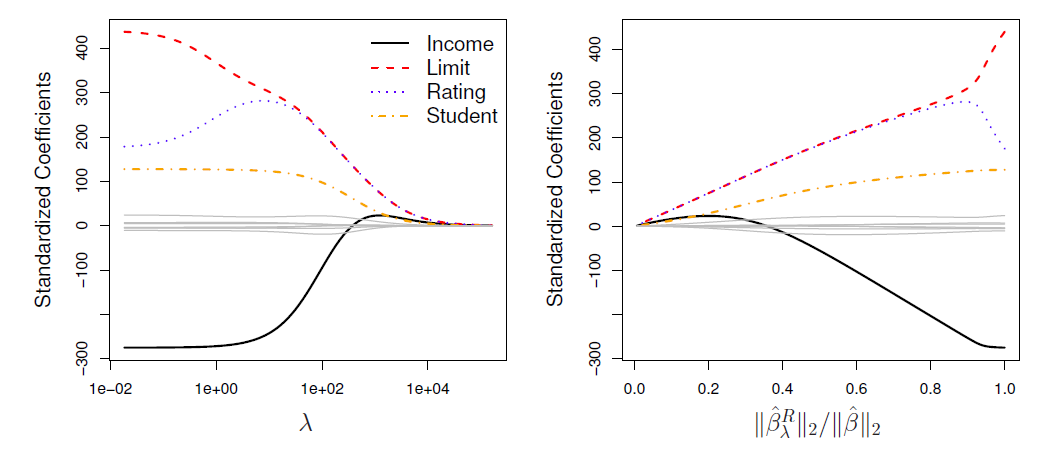

위 그림의 왼쪽에서 보듯 $\lambda$가 커지면 결국 모든 $\beta$들의 추정치는 0에 가까워진다.

오른쪽 그림에서는 x-축에 $ \dfrac{|| \hat \beta_\lambda^R ||_2}{|| \hat \beta ||_2} $를 표현하였다.

여기서 $|| \cdot ||_2$는 $\ell_2$-norm으로서 다음으로 정의한다.

$$ || \beta ||_2 = \sqrt{\sum_{j=1}^{p} \beta_j^2} $$

한편, ridge regression에서는 predictor들을 **표준화**하여 모형을 적합하는 것이 좋다.


$$ \tilde x_{ij} = \frac{x_{ij} - \bar x_j}{s_j} $$

여기서 $s_j$는 $j$번째 변수의 표준편차이다.

- 변수마다 측정 단위가 다르면 penalty가 공정하게 적용되지 않을 수 있다. 따라서 Ridge와 Lasso를 적용하기 전에 설명변수를 표준화하는 것이 일반적이다.

### Bias-variance tradeoff

50개의 데이터와 45개의 predictor를 이용한 시뮬레이션 실험. 실험에서는 모두 non-zero coefficient를 가정하였다.

아래 그림에서 검은 선이 squared bias, 초록색이 variance, test error가 자주색이다.

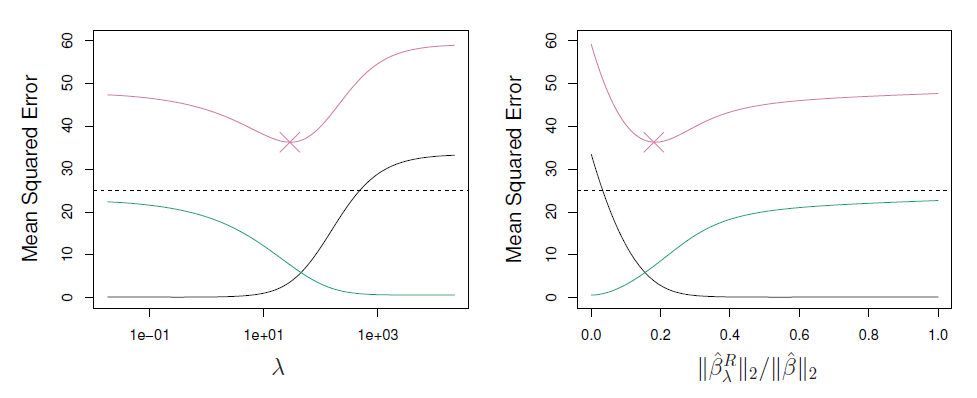

## Lasso 

Ridge regression은 $\lambda$에 따라 coefficient들의 값을 0에 가깝게 보내기는 하지만 완전히 0이 되는 것이 아니기 때문에 최종 모형에는 결국 총 $p$개의 predictor들이 모두 포함된다.

Lasso는 ridge의 대안으로, 다음을 최소화하는 $\beta$들을 찾으며 이를 $\hat \beta_\lambda^L$이라고 하겠다.

$$ \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} |\beta_j| = \mathrm{RSS} + \lambda \sum_{j=1}^{p} |\beta_j| $$

통계적 용어로 이야기하자면, lasso는 $\ell_1$ penalty를 사용하고 ridge는 $\ell_2$ penaltiy를 사용하는 것이다.

Ridge와 마찬가지로 lasso 또한 coefficient 추정치를 0으로 보내지만 ridge와 달리 $\lambda$가 충분히 크면 완전히 0의 값이 된다.

따라서 lasso는 일종의 variable selection 역할을 한다.

Lasso는 sparse 모형을 만들어낸다고도 한다.

마찬가지로 적절한 $\lambda$의 값을 선택하는 것이 중요하며 cross-validation 방법이 이용된다.

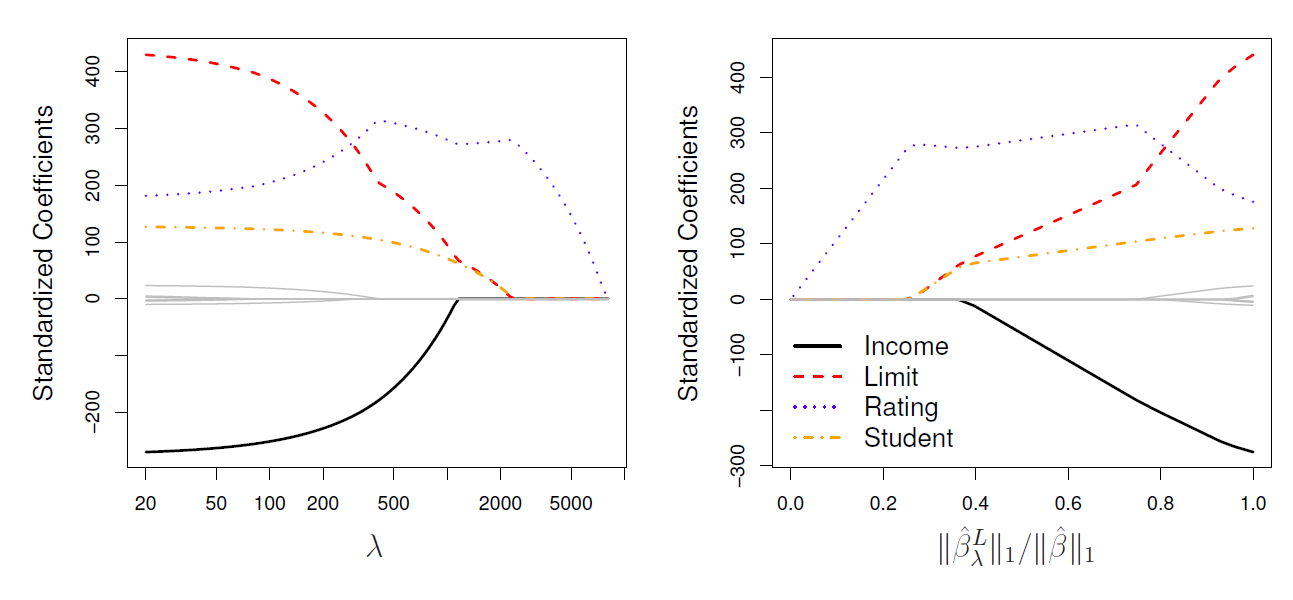

정규화 강도가 커질수록 회귀계수의 절댓값이 작아진다. Lasso에서는 (Ridge와 달리) 일부 계수가 정확히 0이 될 수 있다.

### Ridge와 Lasso의 차이

Lasso와 ridge regression은 각각 결국 다음의 문제를 해결하는 것과 같다.

$$ \arg \min_{\beta} \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2  \text{ subject to }  \sum_{j=1}^{p} |\beta_j| \leq s $$

$$ \arg \min_{\beta} \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2  \text{ subject to }  \sum_{j=1}^{p} \beta_j^2 \leq s $$

그림으로 표현하자면 다음과 같으며, 단순히 Ridge와 Lasso 중 어느 것이 더 낫다고 결론을 지을 수는 없다.

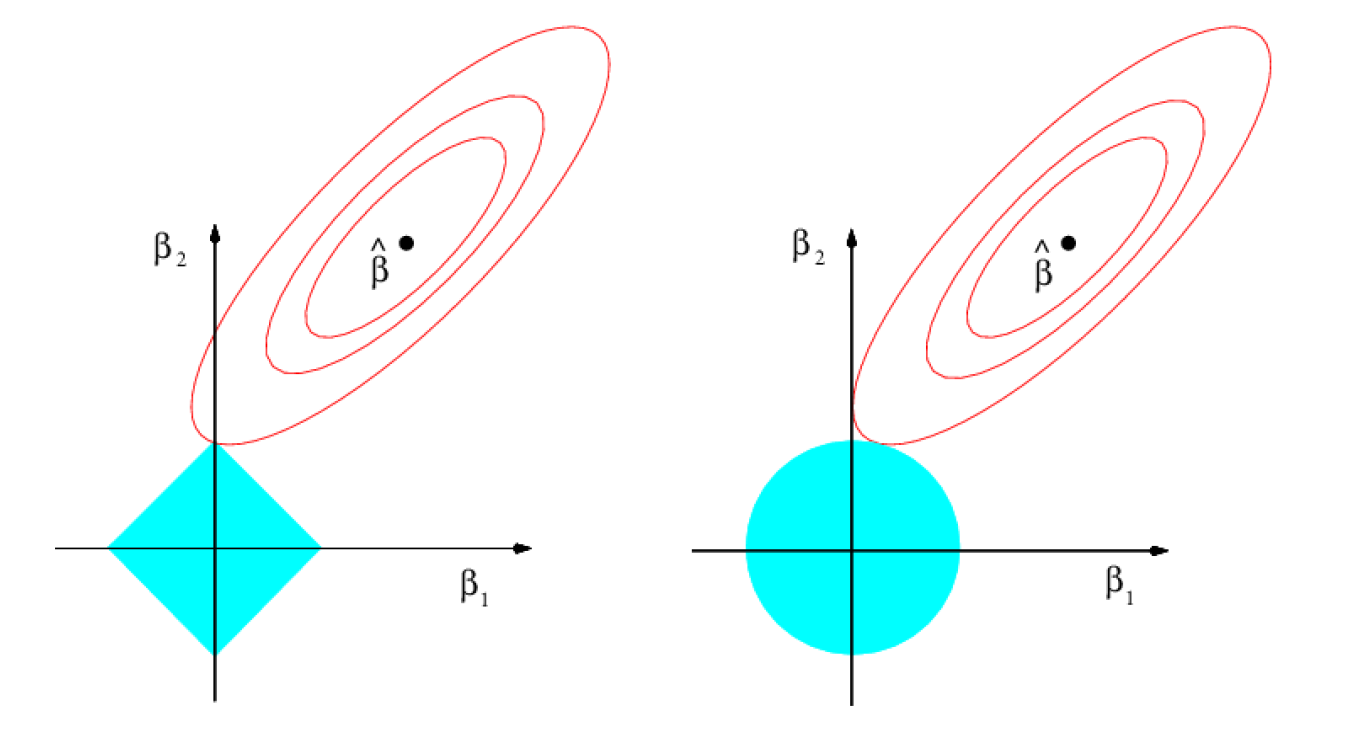

### 모형 선택

앞서 이야기했듯이 $\lambda$는 cross-validation 방법을 통해 정하는 것이 바람직하다.

아래는 먼저 다양한 $\lambda$에 대해 ridge regression을 적합하고, 테스트 자료에서의 MSE를 계산하여 계수와 오차가 $\lambda$에 따라 어떻게 변하는지 살펴보는 예제이다.

(주의: 아래 방법은 alpha 선택을 위해 테스트 자료를 직접 사용한 것으로, cross-validation이 아니며 실제 모형 선택에는 바람직하지 않다. alpha는 이후에 나오는 것처럼 훈련 자료에 대한 cross-validation으로 선택하고, 테스트 자료는 선택된 모형의 최종 성능 평가에만 사용해야 한다.)

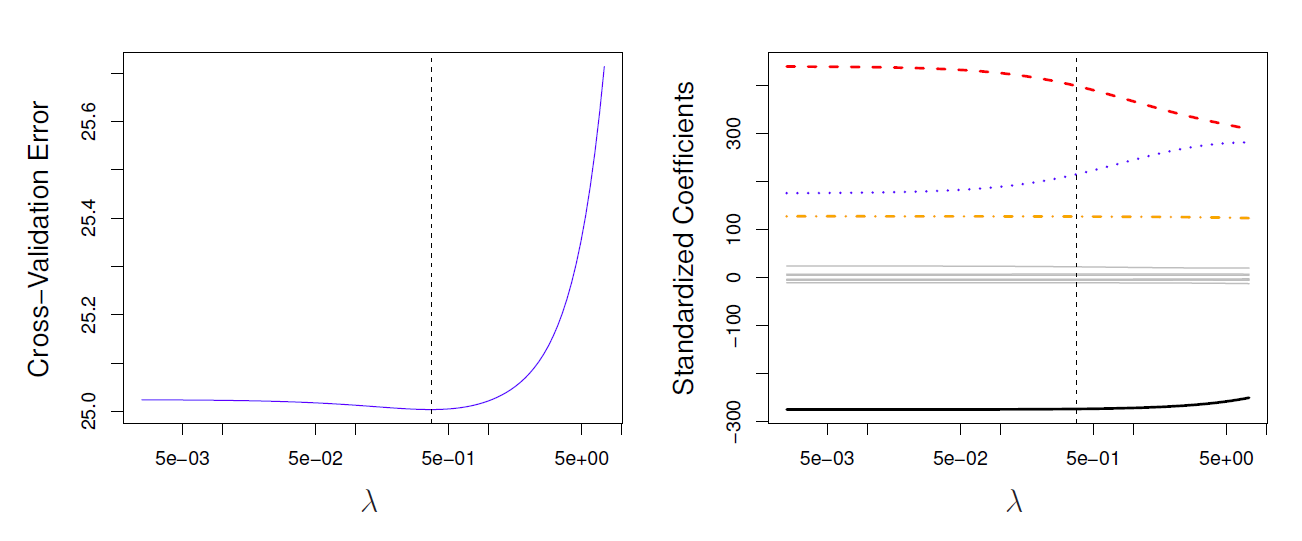

아래는 lasso에 대해서도 마찬가지로, 다양한 $\lambda$에 대해 계수와 테스트 자료에서의 MSE가 어떻게 변하는지 살펴보는 예제이다.

(역시 cross-validation이 아니라 테스트 자료를 이용한 것이므로, 실제 alpha 선택에는 사용하지 않는 것이 좋다.)

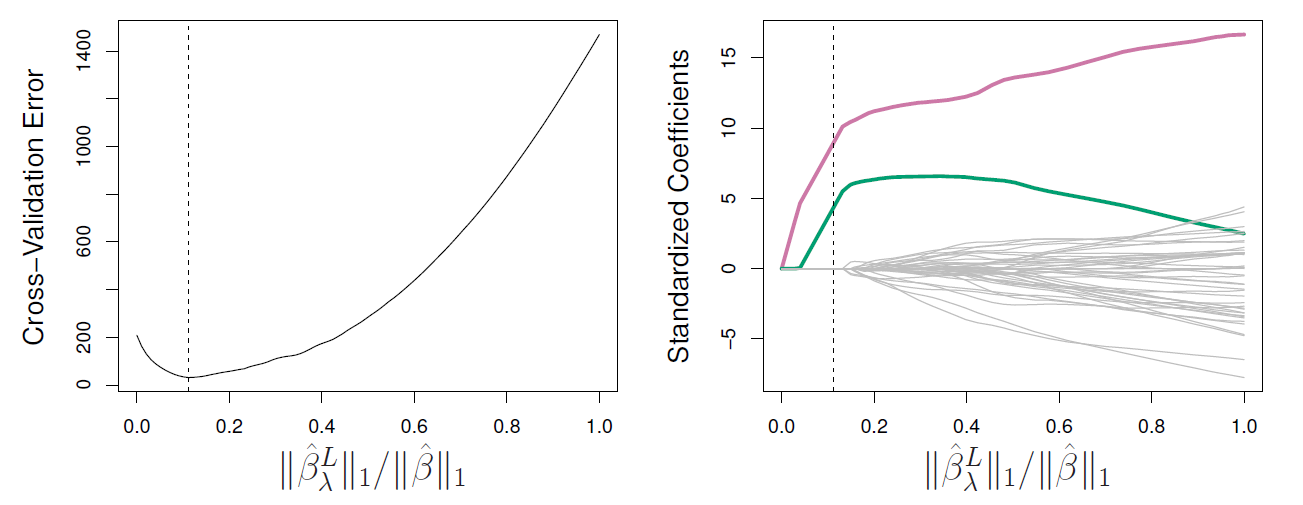

## 엘라스틱넷 (elastic net)

Ridge와 Lasso를 절충한 모델.

그 목적함수는 다음과 같다:

$$
\sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 
+ \lambda \left( r \sum_{j=1}^{p} |\beta_j| + \frac{1 - r}{2} \sum_{j=1}^{p} \beta_j^2 \right)
$$

여기서,

* $\lambda$는 **전체 정규화 강도**를 조절하는 하이퍼파라미터이고,
* $r \in [0, 1]$은 **Lasso와 Ridge 사이의 혼합 비율**이다.

  * $r = 1$이면 Lasso,
  * $r = 0$이면 Ridge,
  * $0 < r < 1$이면 두 기법을 혼합한 형태가 된다.


## sklearn 예제

Boston housing dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True, parser="liac-arff")

X = boston.data.astype(float).values
y = boston.target.astype(float).values

In [2]:
import pandas as pd
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [3]:
pd.DataFrame(y)

,0
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [4]:
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y)

In [5]:
pd.DataFrame(X_tn)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48
1,11.95110,0.0,18.10,0.0,0.659,5.608,100.0,1.2852,24.0,666.0,20.2,332.09,12.13
2,0.03113,0.0,4.39,0.0,0.442,6.014,48.5,8.0136,3.0,352.0,18.8,385.64,10.53
3,0.41238,0.0,6.20,0.0,0.504,7.163,79.9,3.2157,8.0,307.0,17.4,372.08,6.36
4,13.67810,0.0,18.10,0.0,0.740,5.935,87.9,1.8206,24.0,666.0,20.2,68.95,34.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,3.53501,0.0,19.58,1.0,0.871,6.152,82.6,1.7455,5.0,403.0,14.7,88.01,15.02
375,0.03659,25.0,4.86,0.0,0.426,6.302,32.2,5.4007,4.0,281.0,19.0,396.90,6.72
376,0.01439,60.0,2.93,0.0,0.401,6.604,18.8,6.2196,1.0,265.0,15.6,376.70,4.38
377,0.13158,0.0,10.01,0.0,0.547,6.176,72.5,2.7301,6.0,432.0,17.8,393.30,12.04


[`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)와 훈련 데이터를 이용하여 표준화를 하겠다.

In [6]:
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()
std_scale.fit(X_tn)
X_tn_std = std_scale.transform(X_tn)
X_te_std = std_scale.transform(X_te)

In [7]:
pd.DataFrame(X_tn_std)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.409618,-0.467094,0.127212,-0.260011,0.149243,0.781206,0.726096,-0.673898,-0.973154,-0.794929,1.171437,0.399345,-0.908587
1,1.060826,-0.467094,1.057113,-0.260011,0.889472,-0.959137,1.106901,-1.216914,1.694451,1.566080,0.793787,-0.271712,-0.087872
2,-0.419361,-0.467094,-1.009167,-0.260011,-0.978316,-0.363371,-0.725946,2.093436,-0.741189,-0.320324,0.132900,0.313932,-0.320287
3,-0.372018,-0.467094,-0.736376,-0.260011,-0.444662,1.322678,0.391557,-0.267115,-0.161274,-0.590668,-0.527987,0.165634,-0.926018
4,1.275279,-0.467094,1.057113,-0.260011,1.586664,-0.479296,0.676271,-0.953499,1.694451,1.566080,0.793787,-3.149514,3.091852
...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,0.015741,-0.467094,1.280168,3.845994,2.714222,-0.160869,0.487648,-0.990448,-0.509223,-0.013933,-1.802555,-2.941066,0.331927
375,-0.418683,0.666542,-0.938331,-0.260011,-1.116033,0.059242,-1.306051,0.807898,-0.625206,-0.746867,0.227312,0.437075,-0.873725
376,-0.421439,2.253633,-1.229208,-0.260011,-1.331215,0.502399,-1.782947,1.210794,-0.973154,-0.842990,-1.377699,0.216160,-1.213631
377,-0.406887,-0.467094,-0.162158,-0.260011,-0.074548,-0.125651,0.128196,-0.506028,-0.393240,0.160289,-0.339162,0.397704,-0.100946


In [8]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_tn_std, y_tn)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.71, 0.77, 0.16,...,-2.09, 0.65,-3.85]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[47.89,23.11,21.71,..., 8.45, 8.01, 4.66]"


In [9]:
print(lr.coef_, lr.intercept_)

[-0.70750317  0.7698522   0.15682771  0.39833655 -2.25343259  2.26170871
  0.12856485 -2.87188205  2.78768635 -2.47036495 -2.09085747  0.65382338
 -3.854565  ] 22.10870712401059


### sklearn에서의 Ridge, Lasso regression

[```sklearn.linear_model.Ridge```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

minimize ```||y - Xw||^2_2 + alpha * ||w||^2_2```

scikit-learn에서는 정규화 강도를 `alpha`로 지정한다. `alpha`가 클수록 회귀계수가 더 많이 축소된다.

In [10]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1)   
ridge.fit(X_tn_std, y_tn)
print(ridge.coef_, ridge.intercept_)

[-0.69744047  0.74872765  0.11589733  0.40366145 -2.21267568  2.27355251
  0.11680693 -2.83540687  2.67380536 -2.35635521 -2.07891923  0.65452623
 -3.83413709] 22.10870712401059


다양한 튜닝 파라미터 `alpha`에 대해 진행해 보자.

In [11]:
import numpy as np
from sklearn.metrics import mean_squared_error

alphas = np.array([0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000])

coefs = []
errs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_tn_std, y_tn)
    coefs.append(ridge.coef_)
    errs.append(mean_squared_error(y_te, ridge.predict(X_te_std)))

In [12]:
pd.DataFrame(coefs)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.707399,0.769633,0.156399,0.398392,-2.253016,2.261832,0.128444,-2.871511,2.786498,-2.469170,-2.090736,0.653830,-3.854357
1,-0.706461,0.767666,0.152559,0.398893,-2.249275,2.262933,0.127356,-2.868180,2.775851,-2.458464,-2.089645,0.653893,-3.852492
2,-0.702373,0.759088,0.135884,0.401063,-2.232829,2.267739,0.122595,-2.853495,2.729524,-2.411997,-2.084836,0.654173,-3.844268
3,-0.697440,0.748728,0.115897,0.403661,-2.212676,2.273553,0.116807,-2.835407,2.673805,-2.356355,-2.078919,0.654526,-3.834137
4,-0.663868,0.677859,-0.015980,0.420718,-2.065730,2.313452,0.076026,-2.700392,2.299741,-1.990690,-2.034903,0.657349,-3.758222
5,-0.632533,0.611044,-0.131808,0.435556,-1.910819,2.350747,0.035386,-2.551838,1.958378,-1.671749,-1.986623,0.660604,-3.673328
6,-0.531200,0.388904,-0.445423,0.473664,-1.227088,2.436684,-0.125043,-1.797027,0.863727,-0.814065,-1.734773,0.669091,-3.188497
7,-0.497968,0.318458,-0.519923,0.475854,-0.885563,2.372488,-0.199537,-1.314436,0.442652,-0.601598,-1.553978,0.655862,-2.802034
8,-0.439940,0.295591,-0.523789,0.362400,-0.451060,1.605482,-0.307168,-0.299044,-0.154792,-0.465060,-0.988028,0.507588,-1.624526
9,-0.382656,0.281173,-0.463835,0.259323,-0.379937,1.129289,-0.306392,-0.046637,-0.242068,-0.421918,-0.720194,0.403185,-1.143314


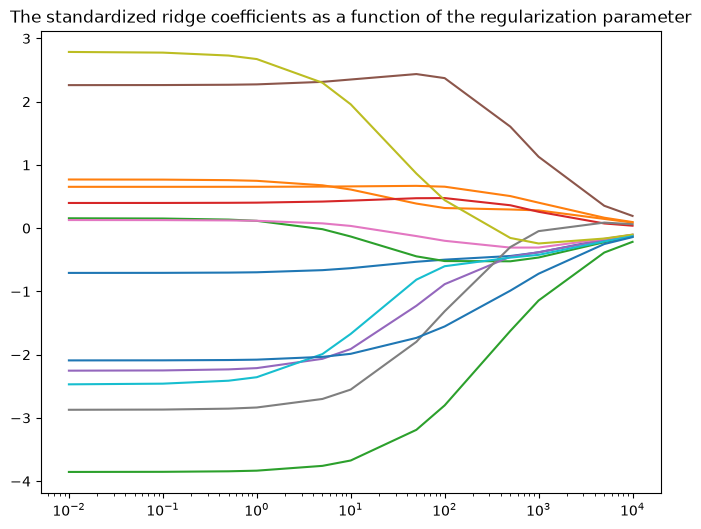

In [13]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.title("The standardized ridge coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

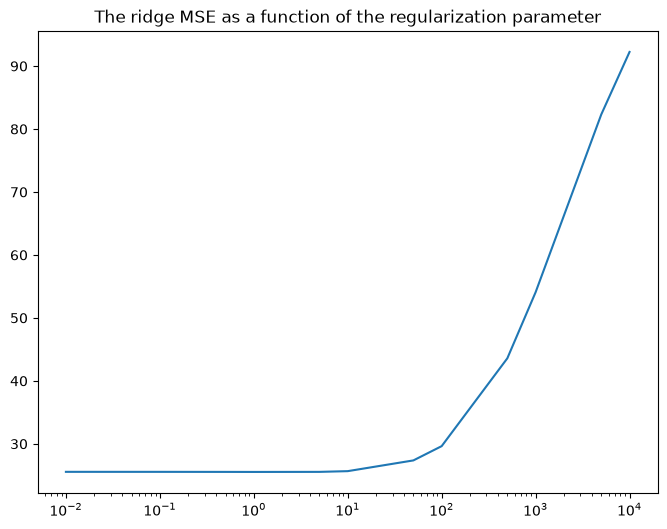

In [14]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs)
ax.set_xscale("log")
plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### [```sklearn.linear_model.Lasso```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)를 이용한 예제

다음을 최소화한다.

minimize 1 / (2 * n_samples)) * ||y - Xw||^2_2 + alpha * ||w||_1

In [15]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 0.1) 
lasso.fit(X_tn_std, y_tn)
print(lasso.coef_, lasso.intercept_)

[-0.40633583  0.36286127 -0.07635589  0.3708157  -1.70297239  2.39553318
  0.         -2.18644883  1.14308636 -1.02221259 -1.93425309  0.56006508
 -3.8117853 ] 22.108707124010586


In [16]:
L_coefs = []
L_errs = []

alphas = np.arange(0.1, 10, 0.1)

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_tn_std, y_tn)
    L_coefs.append(lasso.coef_)
    L_errs.append(mean_squared_error(y_te, lasso.predict(X_te_std)))

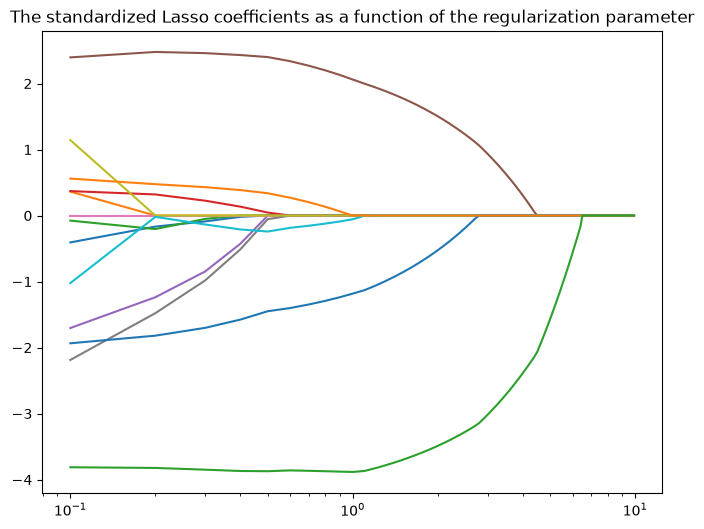

In [17]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_coefs)
ax.set_xscale("log")
plt.title("The standardized Lasso coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

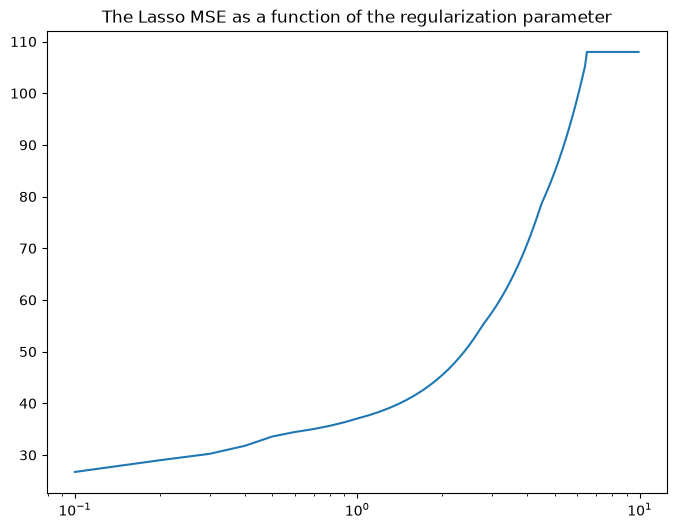

In [18]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_errs)
ax.set_xscale("log")
plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### with K-fold cross validation

앞 단원에서 공부했던 k-fold cross validation 방법을 다시 적용하여 보자.

In [19]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler

alphas = np.arange(0.01, 10, 0.01)

errs_alpha = [] # alpha별 에러

for a in alphas:
    
    kfold_errs = []  # 각 폴드 별 에러
    
    kf = KFold(n_splits = 5, shuffle=True, random_state=1)
    
    for train_index, test_index in kf.split(X):
    
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        std_scale = StandardScaler()
        std_scale.fit(X_train)
        
        X_train_std = std_scale.transform(X_train)
        X_test_std = std_scale.transform(X_test)
        
        ridge = Ridge(alpha = a)
        ridge.fit(X_train_std, y_train)
        
        kfold_errs.append(mean_squared_error(y_test, ridge.predict(X_test_std)))
        
    errs_alpha.append(np.mean(kfold_errs))

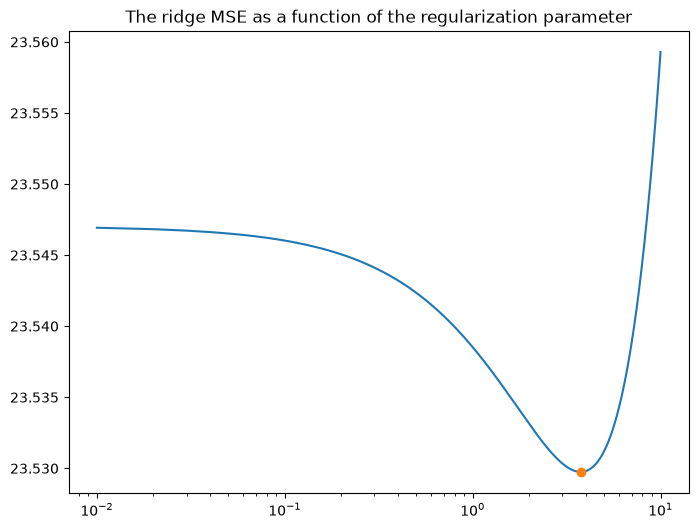

In [20]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

혹은 더 간단하게 `cross_val_score`를 이용한 버전을 살펴보자.

* 아래 코드에서  `'neg_mean_squared_error'`는 MSE의 음수값을 나타내므로, mse 평균을 구할 때는 다시 마이너스를 취한다.

* `cross_val_score` 함수의 기본 동작은 높은 값일수록 좋은 성능으로 간주하도록 되어 있어, 음의 평균 제곱 오차를 사용하도록 구현되어 있다.

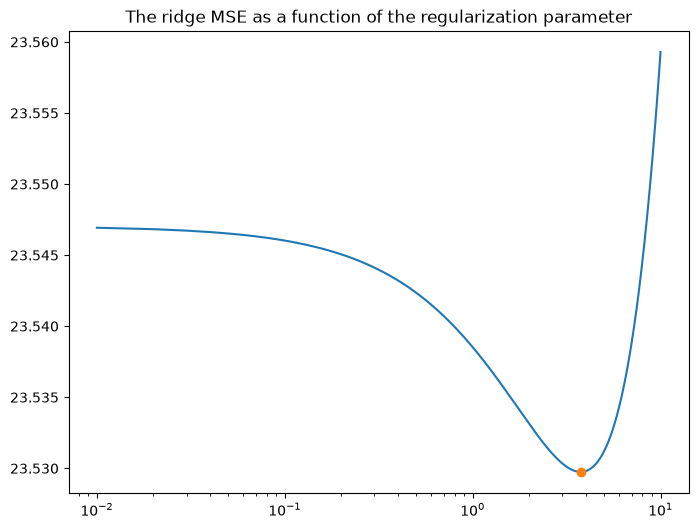

In [21]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# alpha 값들
alphas = np.arange(0.01, 10, 0.01)
errs_alpha = []
cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Ridge 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

Lasso에 대해서도 비슷하게 해 보자.

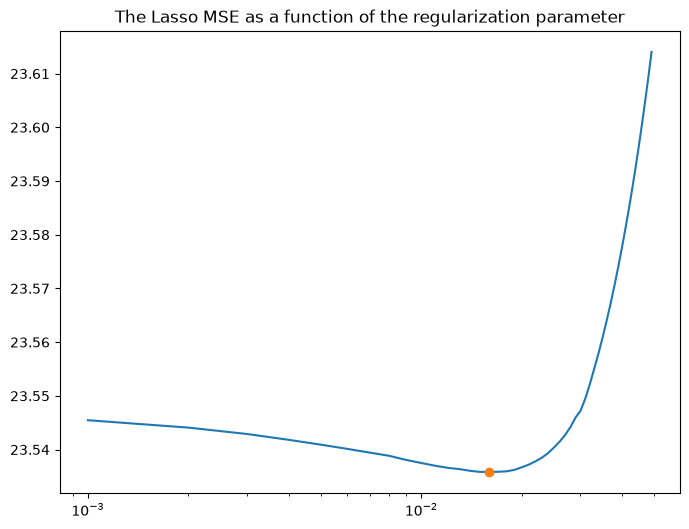

In [22]:

alphas = np.arange(0.001, 0.05, 0.001)
errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Lasso 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### sklearn에서의 ElasticNet

[```sklearn.linear_model.ElasticNet```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

minimize 1 / (2 * n_samples) * ||y - Xw||^2_2 + alpha * l1_ratio * ||w||_1 + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2

In [23]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha = 0.1, l1_ratio = 0.5)
elastic.fit(X_tn_std, y_tn)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [24]:
print(elastic.coef_, elastic.intercept_)

[-0.48390775  0.39563812 -0.275596    0.42262333 -1.51289284  2.42283508
 -0.         -2.04193905  1.07423427 -0.95196161 -1.85580538  0.61928365
 -3.54724143] 22.108707124010586


In [25]:
ridge = Ridge(alpha=1).fit(X_tn_std, y_tn)
lasso = Lasso(alpha=0.1).fit(X_tn_std, y_tn)

pred_lr = lr.predict(X_te_std)
pred_ridge = ridge.predict(X_te_std)
pred_lasso = lasso.predict(X_te_std)
pred_elastic = elastic.predict(X_te_std)


In [26]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_te, pred_lr))
print(mean_squared_error(y_te, pred_ridge))
print(mean_squared_error(y_te, pred_lasso))
print(mean_squared_error(y_te, pred_elastic))

25.549021574461797
25.532482854205345
26.722020660819215
26.709535201497154


### Hitter example

여러 지표를 바탕으로 야구(타자) 선수의 연봉을 예측하는 문제.

여기서는 예제를 단순화하기 위해 범주형 변수를 제외한다. 실제 분석에서는 one-hot encoding을 적용하여 포함할 수 있다.

In [27]:
import pandas as pd
df = pd.read_csv('https://gist.githubusercontent.com/keeganhines/59974f1ebef97bbaa44fb19143f90bad/raw/d9bcf657f97201394a59fffd801c44347eb7e28d/Hitters.csv')
df = df.dropna(axis=0)
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N
5,-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,...,501,336,194,A,W,282,421,25,750.0,A


In [28]:
from sklearn.model_selection import train_test_split

y = df["Salary"]
X = df.iloc[:, 1:]
X = X.drop(["Salary", "League", "Division", "NewLeague"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [29]:
from sklearn.preprocessing import StandardScaler

std_scale = StandardScaler()
std_scale.fit(X_train)
X_train_std = std_scale.transform(X_train)
X_test_std = std_scale.transform(X_test)

In [30]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1)   
ridge.fit(X_train_std, y_train)
print(ridge.coef_, ridge.intercept_)

[-246.99690378  202.96960433   13.38312066   -8.13042899   13.52407687
  113.27401074  -82.21716535 -166.78402604  182.76865581   97.84615424
  378.59067979  -63.05832111 -127.52823368   76.21949353   53.9598804
  -19.35612578] 527.8088324873096


In [31]:
import numpy as np
from sklearn.metrics import mean_squared_error

alphas = np.array([0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000])

coefs = []
errs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_std, y_train)
    coefs.append(ridge.coef_)
    errs.append(mean_squared_error(y_test, ridge.predict(X_test_std)))

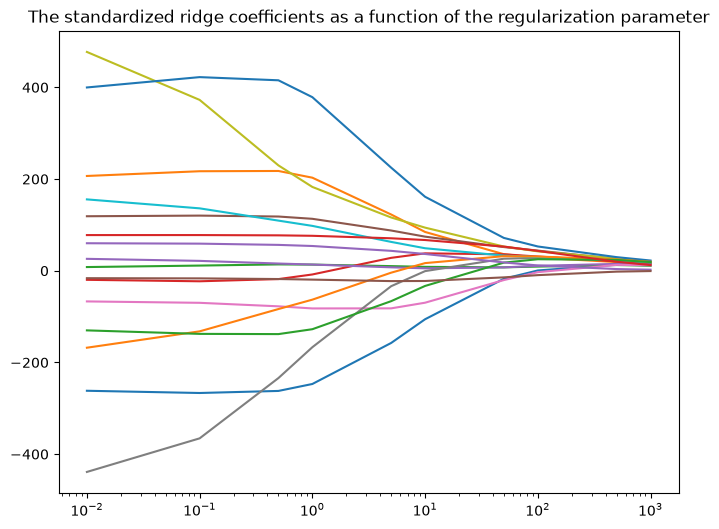

In [32]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.title("The standardized ridge coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

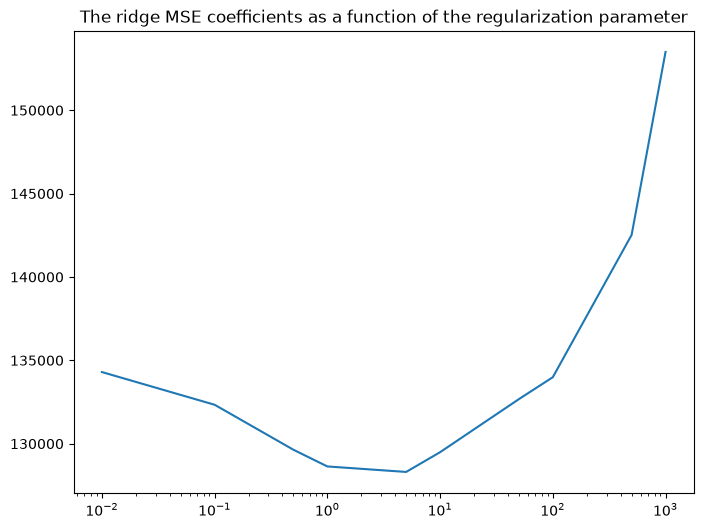

In [33]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs)
ax.set_xscale("log")
plt.title("The ridge MSE coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

In [34]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 1) 
lasso.fit(X_train_std, y_train)
print(lasso.coef_, lasso.intercept_)

[-262.32159758  227.2675858    17.01451738  -14.86325178    6.57568823
  114.70548568  -76.88169553  -96.19121763    0.           60.39204335
  475.79933324    0.         -147.31916702   76.77356632   50.05274624
  -14.85272549] 527.8088324873097


In [35]:
L_coefs = []
L_errs = []

alphas = np.array([0.5, 1, 2.5, 5, 10, 25, 50, 100])

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=2000)
    lasso.fit(X_train_std, y_train)
    L_coefs.append(lasso.coef_)
    L_errs.append(mean_squared_error(y_test, lasso.predict(X_test_std)))

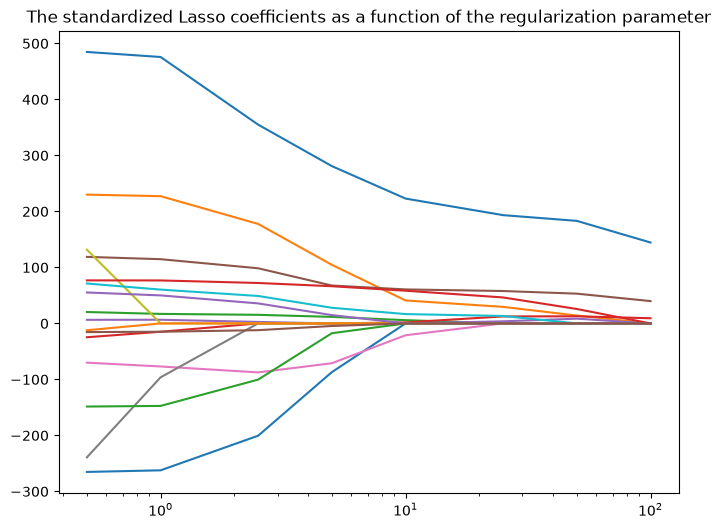

In [36]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_coefs)
ax.set_xscale("log")
plt.title("The standardized Lasso coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

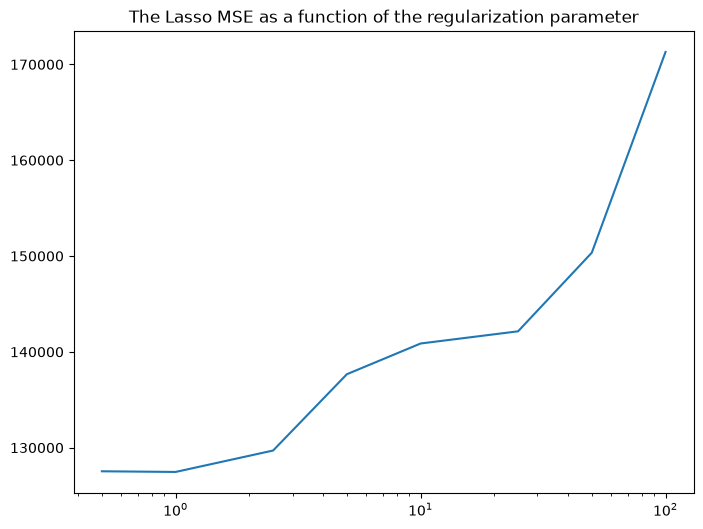

In [37]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_errs)
ax.set_xscale("log")
plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

#### With k-fold cross-validation

Ridge regression을 이용하여 앞에서 했던 내용을 반복해 보자.

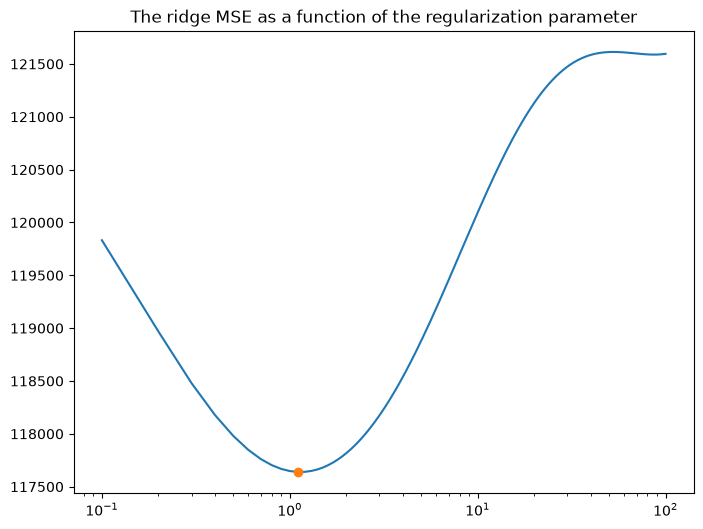

In [38]:
from sklearn.model_selection import KFold
alphas = np.arange(0.1, 100, 0.1)

errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Ridge 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

Lasso regression을 이용하여 같은 방법을 다시 적용하여 보았다.

In [39]:
from sklearn.model_selection import KFold
alphas = np.arange(1, 10, 0.02)

errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Lasso 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=a, max_iter=2000))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


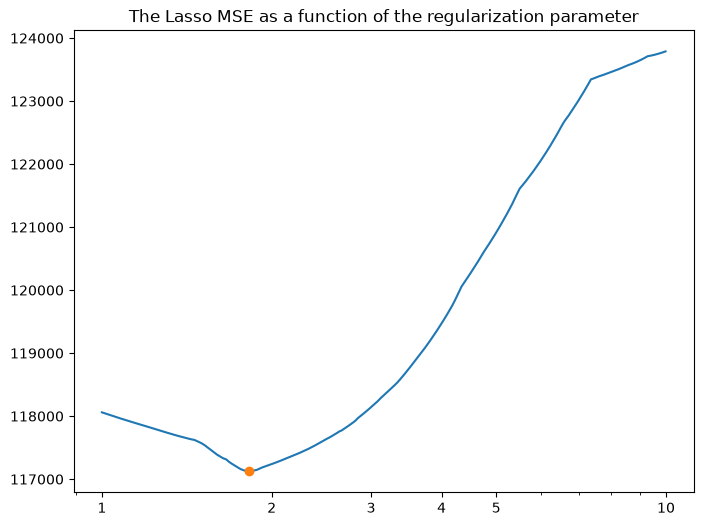

In [40]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')
plt.xticks([1, 2, 3, 4, 5, 10], ['1', '2', '3', '4', '5', '10'])

plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()